In [ ]:
import platform, struct, sys

print(sys.executable)
print(platform.python_version())
print(struct.calcsize("P") * 8)

import sys

print(sys.executable)

from xgboost import XGBRegressor

print("XGBoost imported successfully")

/usr/local/bin/python3
3.13.3
64
/usr/local/bin/python3
XGBoost imported successfully


In [ ]:
# Flood Risk Modeling

# 1. Load datasets

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import KFold, cross_validate
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error


# 1. Load datasets

train_df = pd.read_csv("./data/flood_train_scaled.csv")
test_df = pd.read_csv("./data/flood_test_scaled.csv")

TARGET = "FloodProbability"

X_train = train_df.drop(columns=[TARGET])
y_train = train_df[TARGET]

X_test = test_df.drop(columns=[TARGET])
y_test = test_df[TARGET]

print("Train shape:", X_train.shape, y_train.shape)
print("Test shape: ", X_test.shape, y_test.shape)

Train shape: (40000, 20) (40000,)
Test shape:  (10000, 20) (10000,)


In [ ]:
# 2. Shared evaluation helpers

cv = KFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "r2": "r2",
    "rmse": "neg_root_mean_squared_error",
    "mae": "neg_mean_absolute_error",
}


def summarize_cv(cv_results, model_name):
    summary = pd.DataFrame(
        {
            "Model": [model_name],
            "CV_R2_Mean": [cv_results["test_r2"].mean()],
            "CV_R2_SD": [cv_results["test_r2"].std()],
            "CV_RMSE_Mean": [-cv_results["test_rmse"].mean()],
            "CV_RMSE_SD": [cv_results["test_rmse"].std()],
            "CV_MAE_Mean": [-cv_results["test_mae"].mean()],
            "CV_MAE_SD": [cv_results["test_mae"].std()],
        }
    )
    return summary


def evaluate_test(y_true, y_pred, model_name):
    return pd.DataFrame(
        {
            "Model": [model_name],
            "Test_R2": [r2_score(y_true, y_pred)],
            "Test_RMSE": [np.sqrt(mean_squared_error(y_true, y_pred))],
            "Test_MAE": [mean_absolute_error(y_true, y_pred)],
        }
    )


def residual_plots(y_true, y_pred, model_name):
    residuals = y_true - y_pred

    # Residuals vs fitted
    plt.figure(figsize=(7, 5))
    plt.scatter(y_pred, residuals, alpha=0.35)
    plt.axhline(0, linestyle="--")
    plt.xlabel("Predicted Flood Probability")
    plt.ylabel("Residuals")
    plt.title(f"{model_name}: Residuals vs Fitted")
    plt.show()

    # Residual histogram
    plt.figure(figsize=(7, 5))
    plt.hist(residuals, bins=30)
    plt.xlabel("Residual")
    plt.ylabel("Count")
    plt.title(f"{model_name}: Residual Distribution")
    plt.show()


def stratified_error_table(X, y_true, y_pred, stratify_col, q=4):
    df_eval = X.copy()
    df_eval["actual"] = y_true.values
    df_eval["pred"] = y_pred
    df_eval["abs_error"] = np.abs(df_eval["actual"] - df_eval["pred"])

    # Quantile bins
    df_eval["bin"] = pd.qcut(df_eval[stratify_col], q=q, duplicates="drop")

    out = (
        df_eval.groupby("bin", observed=False)
        .agg(
            n=("abs_error", "size"),
            mean_abs_error=("abs_error", "mean"),
            rmse=(
                "pred",
                lambda s: np.sqrt(np.mean((df_eval.loc[s.index, "actual"] - s) ** 2)),
            ),
        )
        .reset_index()
    )
    return out

XGBoost CV Summary


,Model,CV_R2_Mean,CV_R2_SD,CV_RMSE_Mean,CV_RMSE_SD,CV_MAE_Mean,CV_MAE_SD
0,XGBoost,0.926467,0.000694,0.013575,0.000073,0.010571,0.000068


XGBoost Test Summary


,Model,Test_R2,Test_RMSE,Test_MAE
0,XGBoost,0.927183,0.013467,0.010515


Top 10 XGBoost Features


,Feature,Importance
1,TopographyDrainage,0.054078
19,PoliticalFactors,0.052962
2,RiverManagement,0.052707
12,CoastalVulnerability,0.052166
0,MonsoonIntensity,0.051590
8,AgriculturalPractices,0.050903
13,Landslides,0.050892
14,Watersheds,0.050770
11,DrainageSystems,0.050546
10,IneffectiveDisasterPreparedness,0.050463


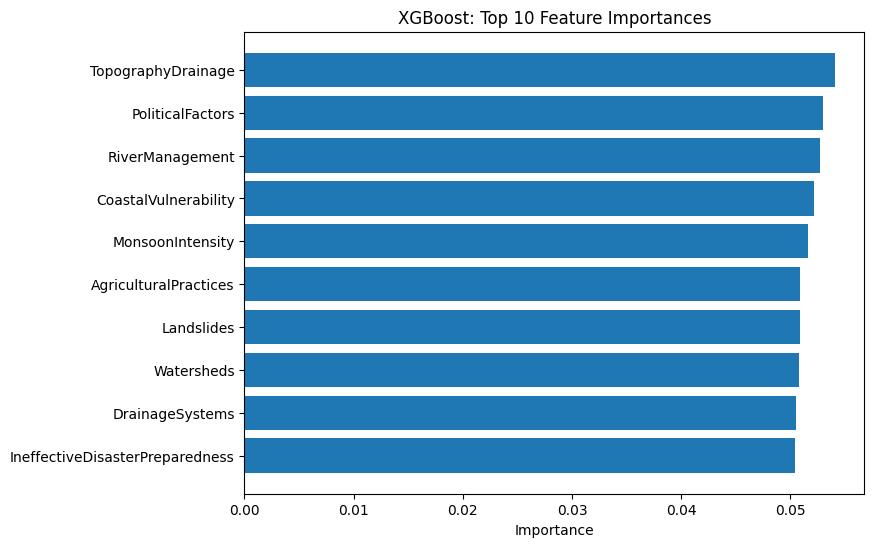

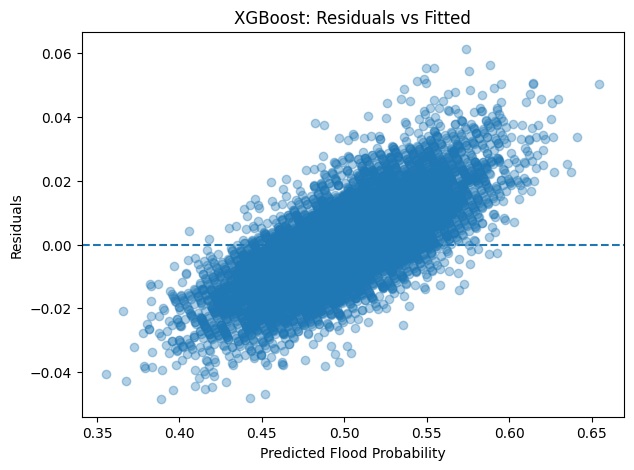

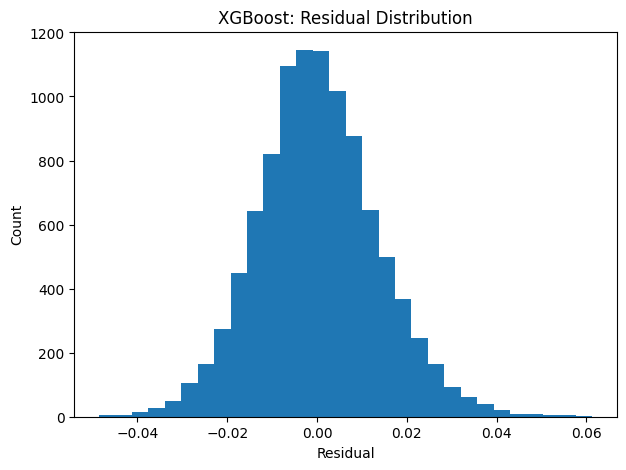

XGBoost error by MonsoonIntensity quartile


,bin,n,mean_abs_error,rmse
0,"(-2.2319999999999998, -0.889]",2653,0.010694,0.013537
1,"(-0.889, 0.00609]",3507,0.010060,0.012963
2,"(0.00609, 0.454]",1444,0.010601,0.013515
3,"(0.454, 4.034]",2396,0.010932,0.014070


XGBoost error by Deforestation quartile


,bin,n,mean_abs_error,rmse
0,"(-2.254, -0.903]",2584,0.010534,0.013377
1,"(-0.903, -0.00291]",3553,0.010533,0.013591
2,"(-0.00291, 0.447]",1464,0.010061,0.012727
3,"(0.447, 4.496]",2399,0.010745,0.013813


In [ ]:
# 3. MODEL 1: XGBoost Regressor

from xgboost import XGBRegressor


xgb_model = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    reg_alpha=0.01,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
)

# 5-fold CV
xgb_cv = cross_validate(xgb_model, X_train, y_train, cv=cv, scoring=scoring, n_jobs=1)

xgb_cv_summary = summarize_cv(xgb_cv, "XGBoost")
print("XGBoost CV Summary")
display(xgb_cv_summary)

# Fit on full training set
xgb_model.fit(X_train, y_train)

# Test predictions
xgb_pred = xgb_model.predict(X_test)
xgb_test_summary = evaluate_test(y_test, xgb_pred, "XGBoost")

print("XGBoost Test Summary")
display(xgb_test_summary)

# Feature importance
xgb_importance = pd.DataFrame(
    {"Feature": X_train.columns, "Importance": xgb_model.feature_importances_}
).sort_values("Importance", ascending=False)

print("Top 10 XGBoost Features")
display(xgb_importance.head(10))

plt.figure(figsize=(8, 6))
plt.barh(
    xgb_importance.head(10)["Feature"][::-1],
    xgb_importance.head(10)["Importance"][::-1],
)
plt.xlabel("Importance")
plt.title("XGBoost: Top 10 Feature Importances")
plt.show()

# Residual analysis
residual_plots(y_test, xgb_pred, "XGBoost")

# Error stratified by key risk features
print("XGBoost error by MonsoonIntensity quartile")
display(stratified_error_table(X_test, y_test, xgb_pred, "MonsoonIntensity"))

print("XGBoost error by Deforestation quartile")
display(stratified_error_table(X_test, y_test, xgb_pred, "Deforestation"))

Decision Tree CV Summary


,Model,CV_R2_Mean,CV_R2_SD,CV_RMSE_Mean,CV_RMSE_SD,CV_MAE_Mean,CV_MAE_SD
0,Decision Tree,0.126975,0.00714,0.046774,0.000134,0.037292,0.000129


Decision Tree Test Summary


,Model,Test_R2,Test_RMSE,Test_MAE
0,Decision Tree,0.10961,0.047091,0.037535


Top 10 Decision Tree Features


,Feature,Importance
19,PoliticalFactors,0.233451
3,Deforestation,0.156339
6,DamsQuality,0.098625
16,PopulationScore,0.095717
1,TopographyDrainage,0.061777
0,MonsoonIntensity,0.057302
5,ClimateChange,0.049477
17,WetlandLoss,0.043522
10,IneffectiveDisasterPreparedness,0.043230
15,DeterioratingInfrastructure,0.037796


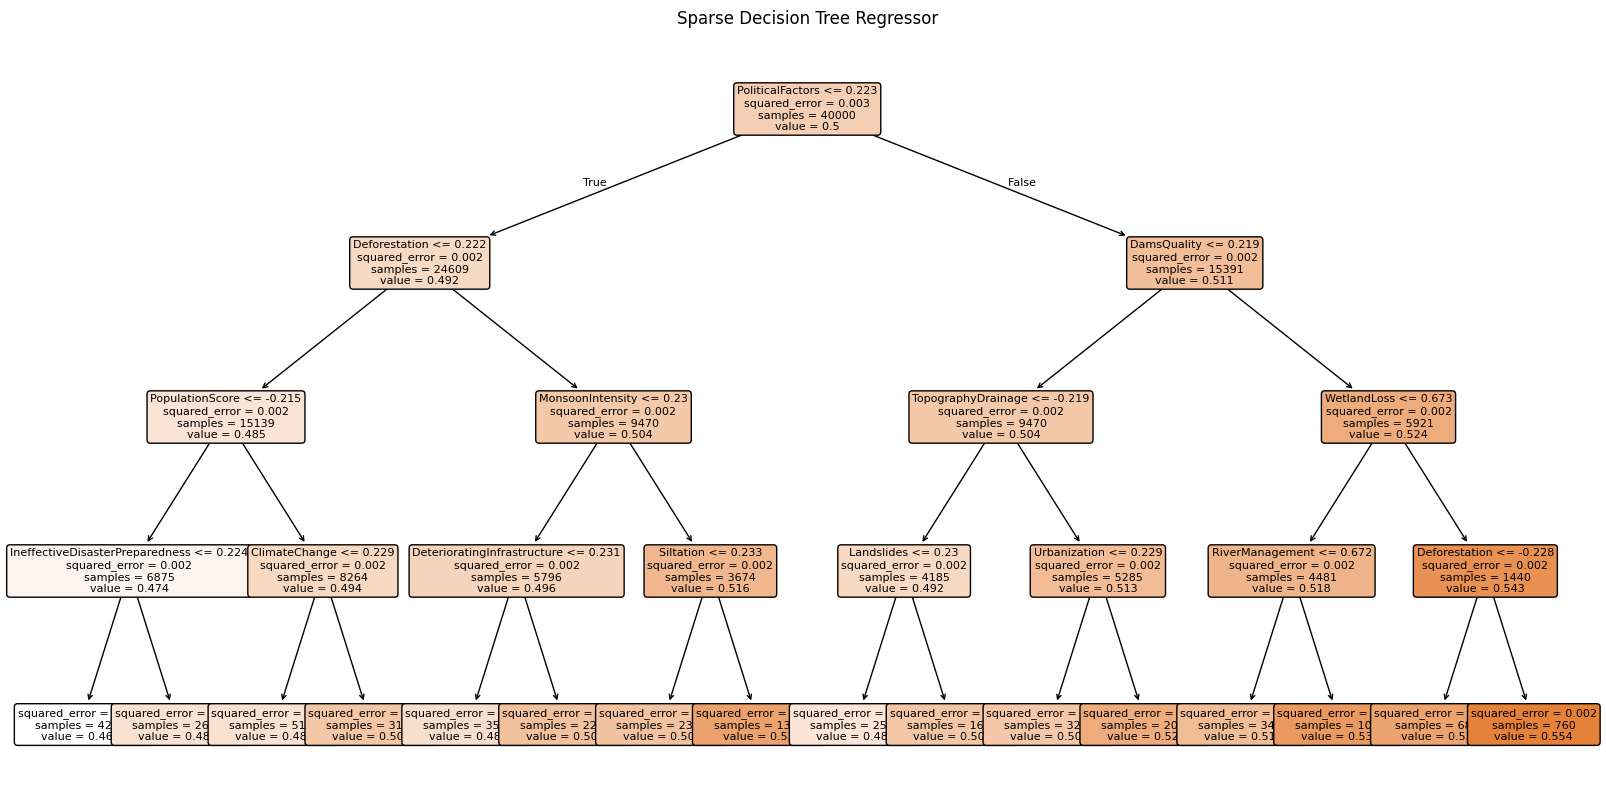

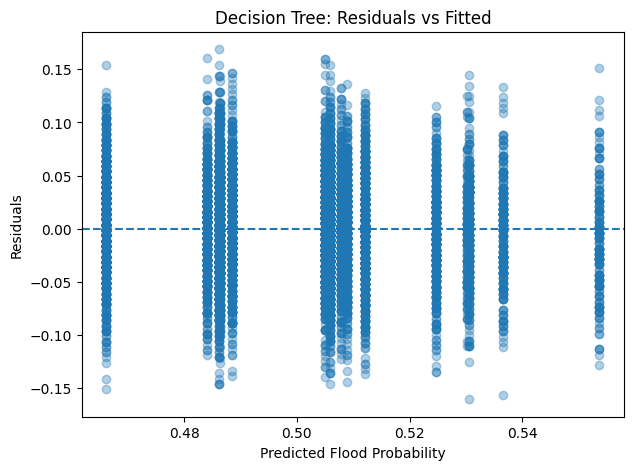

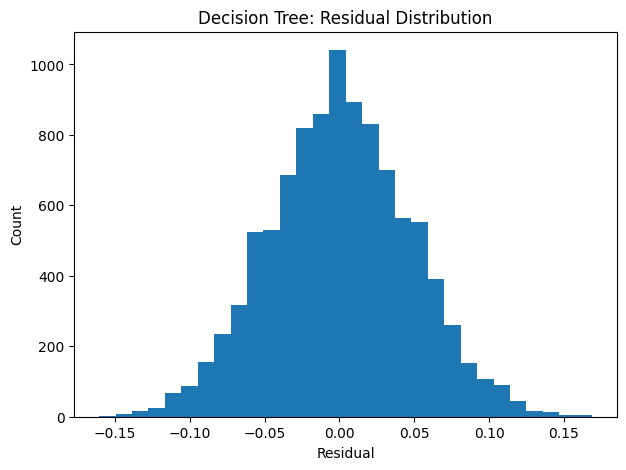

Decision Tree error by MonsoonIntensity quartile


,bin,n,mean_abs_error,rmse
0,"(-2.2319999999999998, -0.889]",2653,0.038012,0.047556
1,"(-0.889, 0.00609]",3507,0.035875,0.045263
2,"(0.00609, 0.454]",1444,0.037667,0.047214
3,"(0.454, 4.034]",2396,0.039355,0.049081


Decision Tree error by Deforestation quartile


,bin,n,mean_abs_error,rmse
0,"(-2.254, -0.903]",2584,0.036749,0.046058
1,"(-0.903, -0.00291]",3553,0.038188,0.048028
2,"(-0.00291, 0.447]",1464,0.037266,0.046647
3,"(0.447, 4.496]",2399,0.037577,0.047060


In [ ]:
# 4. MODEL 2: Sparse / Interpretable Decision Tree Regressor

from sklearn.tree import DecisionTreeRegressor, plot_tree

tree_model = DecisionTreeRegressor(
    max_depth=4,  # keeps model interpretable / sparse
    min_samples_leaf=50,  # pruning
    random_state=42,
)

# 5-fold CV
tree_cv = cross_validate(tree_model, X_train, y_train, cv=cv, scoring=scoring, n_jobs=1)

tree_cv_summary = summarize_cv(tree_cv, "Decision Tree")
print("Decision Tree CV Summary")
display(tree_cv_summary)

# Fit full model
tree_model.fit(X_train, y_train)

# Predict test set
tree_pred = tree_model.predict(X_test)

tree_test_summary = evaluate_test(y_test, tree_pred, "Decision Tree")
print("Decision Tree Test Summary")
display(tree_test_summary)

# Feature importance
tree_importance = pd.DataFrame(
    {"Feature": X_train.columns, "Importance": tree_model.feature_importances_}
).sort_values("Importance", ascending=False)

print("Top 10 Decision Tree Features")
display(tree_importance.head(10))

# Plot tree
plt.figure(figsize=(20, 10))
plot_tree(
    tree_model, feature_names=X_train.columns, filled=True, rounded=True, fontsize=8
)
plt.title("Sparse Decision Tree Regressor")
plt.show()

# Residual analysis
residual_plots(y_test, tree_pred, "Decision Tree")

print("Decision Tree error by MonsoonIntensity quartile")
display(stratified_error_table(X_test, y_test, tree_pred, "MonsoonIntensity"))

print("Decision Tree error by Deforestation quartile")
display(stratified_error_table(X_test, y_test, tree_pred, "Deforestation"))

In [ ]:
# 5. Final comparison table

final_xgb_summary = pd.DataFrame(
    {
        "Model": ["XGBoost"],
        "CV_R2_Mean": [xgb_cv_summary.loc[0, "CV_R2_Mean"]],
        "CV_RMSE_Mean": [xgb_cv_summary.loc[0, "CV_RMSE_Mean"]],
        "CV_MAE_Mean": [xgb_cv_summary.loc[0, "CV_MAE_Mean"]],
        "Test_R2": [xgb_test_summary.loc[0, "Test_R2"]],
        "Test_RMSE": [xgb_test_summary.loc[0, "Test_RMSE"]],
        "Test_MAE": [xgb_test_summary.loc[0, "Test_MAE"]],
    }
)

final_tree_summary = pd.DataFrame(
    {
        "Model": ["Decision Tree"],
        "CV_R2_Mean": [tree_cv_summary.loc[0, "CV_R2_Mean"]],
        "CV_RMSE_Mean": [tree_cv_summary.loc[0, "CV_RMSE_Mean"]],
        "CV_MAE_Mean": [tree_cv_summary.loc[0, "CV_MAE_Mean"]],
        "Test_R2": [tree_test_summary.loc[0, "Test_R2"]],
        "Test_RMSE": [tree_test_summary.loc[0, "Test_RMSE"]],
        "Test_MAE": [tree_test_summary.loc[0, "Test_MAE"]],
    }
)

final_results = pd.concat([final_xgb_summary, final_tree_summary], ignore_index=True)

print("Final Comparison Table")
display(final_results)

Final Comparison Table


,Model,CV_R2_Mean,CV_RMSE_Mean,CV_MAE_Mean,Test_R2,Test_RMSE,Test_MAE
0,XGBoost,0.926467,0.013575,0.010571,0.927183,0.013467,0.010515
1,Decision Tree,0.126975,0.046774,0.037292,0.109610,0.047091,0.037535
